# finish

In [47]:
#libraries
import numpy as np
from numpy.linalg import inv
import matplotlib.pyplot as plt
import math
import time

In [ ]:
#create dataset
#AR(1) 
def ar_1(n,mu,sigma,phi,seed):
    #y = []
    rng = np.random.default_rng(seed=seed)
    y = np.zeros(n)
    epslon = rng.normal(mu,sigma,n)
    for t in range(1,n):
        y[t] =(phi*y[t-1]) + epslon[t]
    return y

In [ ]:
#create dataset 
#ARMA(1,1)
def arma_11(n,mu,sigma,phiY,phiE,seed):
    rng = np.random.default_rng(seed=seed)
    epslon = rng.normal(mu,sigma,n)
    y = np.zeros(n)
    for t in range(1,n):
        y[t] = (phiY*y[t-1]) + epslon[t] + (phiE*epslon[t-1])     
    return y

In [ ]:
#create dataset
#Mean shift
def mean_shift(n,mu,sigma,shift_mean,phi,seed):
    rng = np.random.default_rng(seed=seed)
    epslon = rng.normal(mu,sigma,n)
    y = epslon.copy()
    y[shift_mean:] += 1.0  
    for t in range(1, n):
        y[t] = (phi*y[t-1]) + ((1-phi)*y[t])
    return y


In [ ]:
#create dataset 
#GARCH(1,1)
def garch(n,mu,sigma,a,phi,b,seed):
    rng = np.random.default_rng(seed=seed)
    epsol = rng.normal(mu,sigma,n)
    y = np.zeros(n)
    for t in range(1,n):
        y[t] = epsol[t]*(np.sqrt(a+(phi*(y[t-1]**2))+b))

    return y


In [ ]:
#convert time-series into x,y
# lag = 3
def dataset(lag,y):
    x  = []
    y_target = []
    full_dataset = []
    for t in range(lag,len(y)):
        x.append(y[t-lag:t])
        y_target.append(y[t])
    #full_dataset = x,y_target
    #print(f'len x:{len(x)} len y:{len(y_target)}')
    return x,y_target 


In [ ]:
#Implement linear regression manually
def fit_linear_regression(X_train,y_train):
    X = np.insert(X_train,0,1,axis=1)
    betas = inv(X.T@X)@X.T@y_train
    return betas

In [54]:
#compute thre prediction using linear regression
def prediction_linear(x,betas):
    y_hat = betas[0]+(betas[1]*x[:,0]) + (betas[2]*x[:,1]) + (betas[3]*x[:,2])
    return y_hat

In [55]:
# prediction of OOB
#B=25 # i have create 20 boostrapped training set.
def prediction_OOB(B,X,y):
        rng = np.random.default_rng(10)
        # one list for each of the 200 original observation 
        oob_predictions = [[] for _ in range(len(X))]
        oob_true_y = [[] for _ in range(len(X))]

        all_betas = []
        for bag in range(B):

                # create boostrapping index
                all_indices = np.arange(len(X))
                boostrap_indices = rng.choice(all_indices,len(X),replace=True)

                # find OOB index
                oob = []
                for i in range(len(X)):
                        if i not in boostrap_indices:        
                                oob.append(i)
                oob = np.array(oob)

                # create training data
                X_boostrap = X[boostrap_indices]
                y_boostrap = y[boostrap_indices]

                # train the regression
                betas = fit_linear_regression(X_boostrap,y_boostrap)
                all_betas.append(betas)

                # OOB data 
                X_oob = X[oob]
                #y_oob = y[oob]

                # prediction OOB
                y_hat_oob = prediction_linear(X_oob,betas)
                #print("OOB:", len(oob))
                #print("Predictions:", len(y_hat_oob))

                # save the predictions in same of out of bag index.
                for index, prediction in zip(oob,y_hat_oob):
                        oob_predictions[index].append(prediction)
                        oob_true_y[index].append(y[index])
                        
        return oob_predictions, oob_true_y, all_betas

In [57]:
#averaging the OOBs' predictions of of each observation 
def average_prediction_OOB(X_train, oob_prediction, all_betas):
    #final_y_true_oob = []
    y_hat_oob = []
    for i in range(len(oob_prediction)):
        if len(oob_prediction[i]) > 0:
            prediction_sum = sum(oob_prediction[i])
            number_predictions = len(oob_prediction[i])
            average_prediction = (prediction_sum / number_predictions)

            y_hat_oob.append(average_prediction)
            #final_y_true_oob.append(oob_true_y[i][0])
        else:
            #uses all bootstrap model
            #this condition is used only if some observation has not been selected by any OOB of all boostrapping.
            prediction_all_model = []
            for betas in all_betas:
                pred = prediction_linear(X_train[i:i+1],betas)
                prediction_all_model.append(pred[0])
            
            prediction_sum = sum(prediction_all_model)
            number_predictions = len(prediction_all_model)
            average_prediction = (prediction_sum / number_predictions)
            y_hat_oob.append(average_prediction)

    y_hat_oob = np.array(y_hat_oob)
    #y_true_oob = np.array(final_y_true_oob)

    return y_hat_oob

In [59]:
#test function compute predcition on all models on X_test
def test(X_test,all_betas):

    y_hat_test = []
    for i in range(len(X_test)):
        #test prediction
        prediction_test_models = []
        for betas in all_betas:
            pred = prediction_linear(X_test[i:i+1],betas)
            prediction_test_models.append(pred[0])

        prediction_sum = sum(prediction_test_models)
        number_prediction = len(prediction_test_models)
        average_prediction = (prediction_sum / number_prediction)
        y_hat_test.append(average_prediction)

    y_hat_test = np.array(y_hat_test)
    return y_hat_test

# y_hat_test = test(X_test,all_betas)
# y_hat_test.shape

In [60]:
#calculate empirical quantile
def quantile(alpha,empsilon):

    #sort epsilon residual
    empsilon_sorted = np.sort(empsilon)

    #quantile calculation
    quantile = math.ceil((1-alpha)*(len(empsilon_sorted)))

    #find resisual value
    q = empsilon_sorted[quantile-1]

    return q

# quant = quantile(.1,empsilon)
# quant


In [ ]:
#implementation of EnbPI(Ensemble Batch Prediction Intervals)
def enbpi(X_train,y_train,X_test,y_test,B,alpha,s):

    #starting time 
    start_time = time.time()
    #1. boostrap + OOB predictions
    #B=25
    oob_prediction , oob_true_y, all_betas = prediction_OOB(B,X_train,y_train)
    #2. average OOB predictions
    y_hat_oob = average_prediction_OOB(X_train,oob_prediction,all_betas)
    #3. initial epsilon (600 residuals)
    empsilon = np.abs(y_train - y_hat_oob)
    #4. 25 model prediction on the 300 X_test 
    y_hat_test = test(X_test,all_betas)
    #5. C starts empty
    C = []
    #6. now follow the test points / batches 
    #s = 10
    for start in range(0,len(X_test),s):
        #i did not understand
        end = min(start+s,len(X_test))
        #quantile
        q = quantile(alpha,empsilon)

        for i in range(start,end):
            lower = y_hat_test[i] - q
            upper = y_hat_test[i] + q
            C.append((lower,upper))
        #observed test
        y_obs = y_test[start:end]
        #compute new residual
        new_empsilon = np.abs(y_obs - y_hat_test[start:end])
        #update residual
        empsilon = np.concatenate((empsilon[len(new_empsilon):],new_empsilon))
    #compute coverage
    covered = []
    for i in range(len(y_test)):
        if (y_test[i]>=C[i][0]) and (y_test[i]<=C[i][1]):
            covered.append(1)
        else:
            covered.append(0)

    coverage_sum = np.sum(covered)
    coverage_len = len(covered)
    coverage_mean = coverage_sum / coverage_len
    #coverage = np.mean(covered)

    #compute width
    width_diff = []

    for i in range(len(y_test)):
        width_diff.append(C[i][1] - C[i][0])

    width_average = np.sum(width_diff) / len(width_diff)  

    #end recording time
    end_time = time.time()
    total_running_time = end_time - start_time

    # print("number of intervals:", len(C))
    # print("coverage:", coverage_mean)
    # print("average width:", width_average)

    # print("first 10 widths:", width_diff[:10])
    # print("min width:", np.min(width_diff))
    # print("max width:", np.max(width_diff))
    # print("std width within run:", np.std(width_diff))
    return C, coverage_mean, width_average, width_diff, total_running_time


In [62]:
def data(ar,arma,ms,ga):    
    arr =[ar,arma,ms,ga]
    #final_gammas = []
    #final_results = []
    final_C = []
    final_coverages = []
    final_widths = []
    final_times = []
    for i in arr:
        #print(gamma, type(gamma))
        start_time = time.time()
        x, y = dataset(3,i)
        x = np.array(x)
        y = np.array(y)

        #split dataset.
        X_train = x[:600]
        y_train = y[:600]

        X_test = x[600:]
        y_test = y[600:]

        C,coverage_mean, width_mean, width_diff, total_running_time = enbpi(X_train,y_train,X_test,y_test,B=25,alpha=.1,s=10)

        end_time = time.time()
        running_time = end_time - start_time
        final_C.append(C)
        final_coverages.append(coverage_mean)
        final_widths.append(width_mean)
        final_times.append(running_time)
    return final_C,final_coverages,final_widths,final_times

ar = ar_1(n=903,mu=0,sigma=1.0,phi=0.8,seed=1234)
arma = arma_11(n=903,mu=0,sigma=1.0,phiY=0.5,phiE=0.4,seed=1234)
ms = mean_shift(n=903,mu=0,sigma=1.0,shift_mean=600,phi=0.3,seed=1234)
ga = garch(n=903,mu=0,sigma=1.0,a=0.3,phi=0.5,b=0.1,seed=1234)
C,coverage,width,timer = data(ar,arma,ms,ga)
coverage,width, timer

([np.float64(0.8933333333333333),
  np.float64(0.9),
  np.float64(0.8133333333333334),
  np.float64(0.9033333333333333)],
 [np.float64(3.3888098685354575),
  np.float64(3.39273900329913),
  np.float64(2.5265442333358177),
  np.float64(2.7891353473030556)],
 [0.29596900939941406,
  0.11399722099304199,
  0.0837860107421875,
  0.10050511360168457])

In [63]:
#wcp wih AR
def confInterval(enpi_di,n_rep):

    names = ['ar','arma','ms','ga']
    coverages = {name: [] for name in names}
    widths = {name: [] for name in names} 

    for seed in range(n_rep):

        #genrate timie siries with actual seed
        ar = ar_1(n=903,mu=0,sigma=1.0,phi=0.8,seed=seed)
        arma = arma_11(n=903,mu=0,sigma=1.0,phiY=0.5,phiE=0.4,seed=seed) 
        ms = mean_shift(n=903,mu=0,sigma=1.0,shift_mean=600,phi=0.3,seed=seed)
        ga = garch(n=903,mu=0,sigma=1.0,a=0.3,phi=0.5,b=0.1,seed=seed)

       #give results aci results of all siries     
        _, coverage_seed, width_seed,_ = data(ar,arma,ms,ga)

        #coverage and width
        for j, name in enumerate(names):
            coverages[name].append(coverage_seed[j])
            widths[name].append(width_seed[j])

    #centre points
    for name in names:
        cov = np.array(coverages[name])
        wid = np.array(widths[name])
        mean_coverage = np.mean(cov)
        mean_width = np.mean(wid)


        #confidence interval coverage level 95%
        std_coverage = np.sqrt(np.sum((cov-mean_coverage)**2)/(len(cov)-1))
        coverage_err =1.96*std_coverage/np.sqrt(len(cov))  
        #test_cove = 1.96*np.std(coverage,ddof=1)/np.sqrt(len(coverage))
        #coverage interval width level 95%
        std_width = np.sqrt(np.sum((wid-mean_width)**2)/(len(cov)-1))
        width_err =1.96*std_width/np.sqrt(len(wid))  
        #test_width = 1.96*np.std(wid,ddof=1)/np.sqrt(len(wid))
        enpi_di[name] = mean_coverage, mean_width, coverage_err, width_err
    #print(f'mean_coverage: {mean_coverage}, coverage_error: {coverage_err}, test_cove: {test_cove}')
    #print(f'mean_width: {mean_width}, width_error: {width_err}, test_width: {test_width}')




    return enpi_di


In [64]:
enpi_di = {}
enpi_di = confInterval(enpi_di,n_rep=50)
#enpi_di

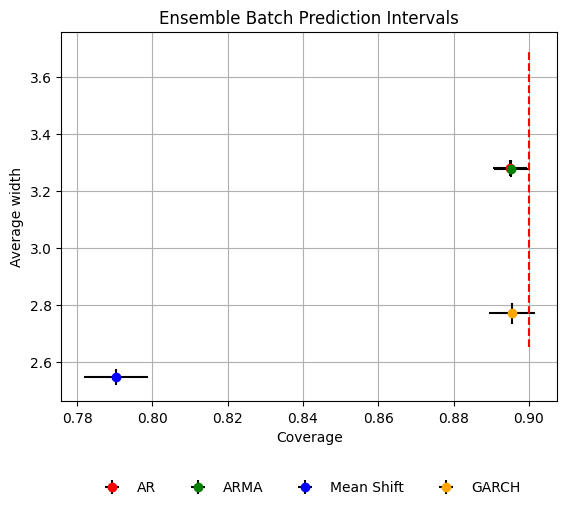

In [65]:
colors = ['red', 'green', 'blue', 'orange']
#colors = ['red']
labels = ['AR', 'ARMA', 'Mean Shift', 'GARCH']
for model, col, lab in zip(['ar','arma','ms','ga'],colors, labels):
    mean_coverage, mean_width, coverage_err, width_err = enpi_di[model]
    plt.errorbar(mean_coverage, mean_width, xerr=coverage_err, yerr=width_err, fmt='o', ecolor='black', color=col,label=lab)
plt.vlines(x=0.90,ymin=2.65,ymax=3.7,colors='r',linestyles='--')
plt.title('Ensemble Batch Prediction Intervals')
plt.xlabel('Coverage')
plt.ylabel('Average width')
# LEGENDA SOTTO "Coverage"
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.18),
    ncol=4,
    frameon=False
)
plt.grid()
plt.show()


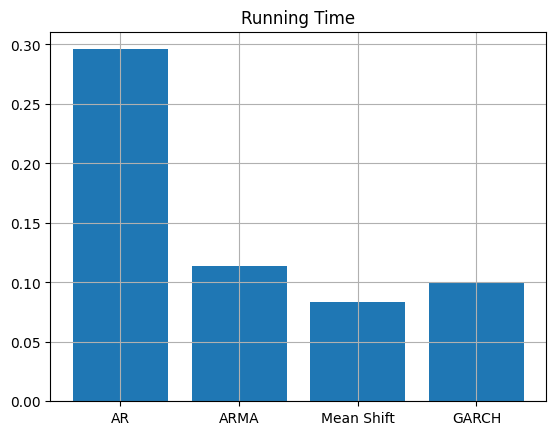

In [66]:
x = ['AR','ARMA','Mean Shift','GARCH']
y = timer
plt.bar(x,y)
plt.title('Running Time')
plt.grid()
plt.show()

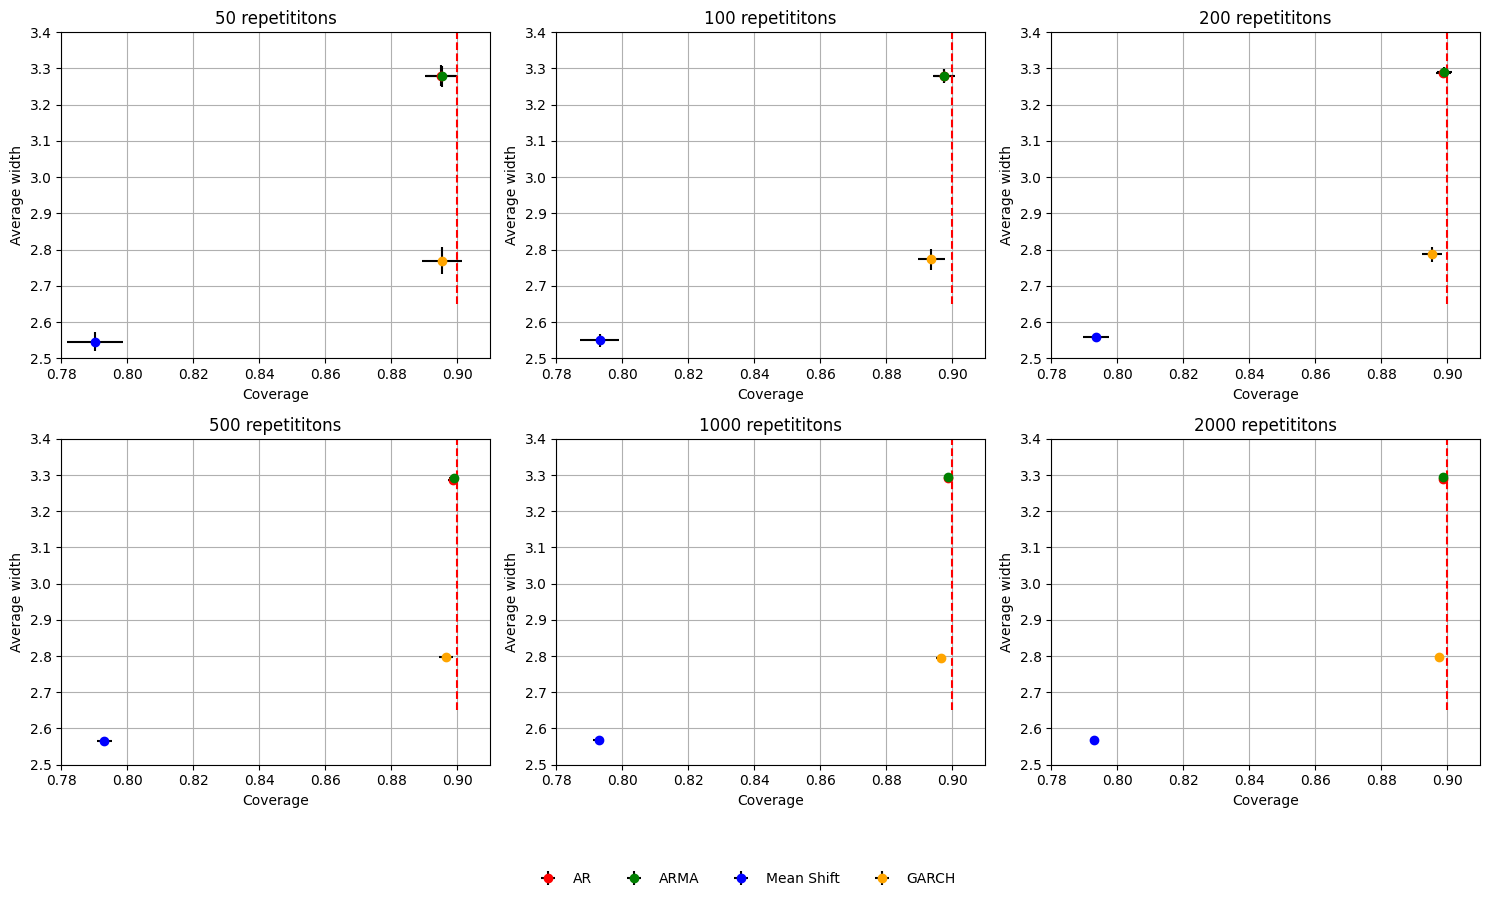

In [70]:
repetiotions = [50,100,200,500,1000,2000]

#repetiotions = [50]
fig, axes = plt.subplots(2, 3, figsize=(15,9))
axes = axes.flatten()
colors = ['red', 'green', 'blue', 'orange']
labels = ['AR', 'ARMA', 'Mean Shift', 'GARCH']
#models = ['ar','arma','ms','ga']
plt.title('Adaptive Conformal Inference')
for k, n_rep in enumerate(repetiotions):
    #recompute confidence interval
    enpi_di = {}
    enpi_di = confInterval(enpi_di,n_rep=n_rep)
    ax = axes[k]

    for model, col, lab in zip(['ar','arma','ms','ga'],colors,labels):
        mean_coverage, mean_width, coverage_err, width_err = enpi_di[model]
        ax.errorbar(mean_coverage, mean_width, xerr=coverage_err, yerr=width_err, fmt='o', ecolor='black', color=col,label=lab)
    ax.vlines(x=0.90,ymin=2.65,ymax=3.7,colors='r',linestyles='--')
    ax.set_xlim(0.78, 0.91)
    ax.set_ylim(2.5, 3.4)
    ax.set_title(f'{n_rep} repetititons')
    ax.set_xlabel('Coverage')
    ax.set_ylabel('Average width')
    ax.grid()

#remuve sith subplot
#fig.delaxes(axes[5])

#one legend for all plot
handles, legend_labels = axes[0].get_legend_handles_labels()

# LEGENDA SOTTO "Coverage"
fig.legend(
    handles,
    legend_labels,
    loc='lower center',
    ncol=4,
    frameon=False
)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()